# Scalar Field Analysis Engine — Quickstart Notebook

Welcome. This notebook is the working surface for a minimal symbolic + numeric analysis tool for `2D scalar fields`.

To get started, Just:

* define a scalar field `f(x, y)`
* differentiate it symbolically
* evaluate it numerically
* inspect its structure

---

## Environment & Dependencies

This project relies on a small, explicit stack:

| Package      | Purpose                               |
| ------------ | ------------------------------------- |
| `sympy`      | Symbolic mathematics                  |
| `numpy`      | Numerical evaluation                  |
| `scipy`      | Distance computations (intersections) |
| `matplotlib` | Visualisation                         |

## Suggested Versions (tested baseline)

```text
sympy==1.13.2
numpy==2.1.2
scipy==1.14.1
matplotlib==3.9.2
```

These version numbers are not gospel, but they *are* known to behave.

---

## Environment Setup (Recommended)

I strongly encourage you to isolate this project in a local virtual environment.

### 1. Create a virtual environment

```bash
py -3.14 -m venv .venv
pip install ipykernel
python -m ipykernel install --user --name scalar-field-venv --display-name "Python (.venv)"
```

### 2. Activate it

**Windows (PowerShell):**

```powershell
.\.venv\Scripts\Activate.ps1
```

**Windows (CMD):**

```cmd
.venv\Scripts\activate.bat
```

**macOS / Linux:**

```bash
source .venv/bin/activate
```

---

## Install Dependencies

Once the environment is active:

```bash
pip install sympy==1.13.2
pip install numpy==2.1.2
pip install scipy==1.14.1
pip install matplotlib==3.9.2
```

Or if you prefer a lighter touch:

```bash
pip install sympy numpy scipy matplotlib
```

---

## What This Notebook Does

This notebook lets you:

1. Define a scalar field:

    ```py
        f = x**3 - 3*x*y**2
    ```

2. Run it through the analysis pipeline

3. Visualise:

   * the scalar field
   * its partial derivatives
   * zero-contours of the gradient
   * approximate critical points

...if everything works as intended, that is!

# Jupyter Kernel Troubleshooting (VSCode)

If you encounter errors like
```PyLance
ModuleNotFoundError: No module named 'sympy'
```
even after installing dependencies, your notebook is likely not using your virtual environment correctly.

## Fix (CLI-based, reliable)
To fix this issue, try:
1) Activate your virtual environment:
    ```bash
        .\.venv\Scripts\Activate.ps1
    ```

2) Register the environment as a Jupyter kernel:
    ```bash
        python -m ipykernel install --user --name scalar-field-venv --display-name "Python (.venv)"
    ```

3) Restart the kernel (or VSCode if necessary)
4) In the notebook, select the kernel `Python (.venv)` from the kernel picker (top right).

---

If you're having trouble *finding* the aforementioned kernel,
it should be under try navigating through the following steps:
> Select Another Kernel...

> Jupyter Kernel...

> Python (.venv) (Python 3.14.3)

# Important Notes

* Critical points are **numerically approximated**, NOT solved exactly!
* Results depend on:

  * grid resolution
  * contour extraction
  * intersection thresholds
* Flat regions and near-degenerate gradients may produce noise

This is an *analytical probe*, not a theorem prover.

In [8]:
from __future__ import annotations

import matplotlib.pyplot as plt
import numpy as np
import sympy as sp

In [9]:
from field_analysis import GridSpec, analyse_scalar_field
from plotting import plot_analysis_summary

In [10]:
# Symbolic variables
x, y = sp.symbols("x y", real=True)


# === 1. Define the scalar field ===
# Replace this expression with any reasonable scalar field f(x, y).
expr = x**3 - 3 * x * y**2


# === 2. Configure the analysis grid ===
# Notes:
# - Larger resolutions give cleaner contours, but cost more time.
# - Wider ranges reveal more global structure, but may hide local detail.
x_range=(-2.5, 2.5)
y_range=(-2.5, 2.5)

resolution=(400, 400)
ANTI_OVERSAMPLE = True  # Set to False to disable anti-oversampling
                        # (not recommended)

grid = GridSpec(
    x_range, y_range,
    resolution,
)


In [11]:
# === 3. Run the scalar-field analysis ===
result = analyse_scalar_field(
    expr,
    variables=(x, y),
    grid=grid,
    intersection_threshold=5e-2,
    deduplication_tolerance=7.5e-2,
)


# === 4. Inspect the symbolic outputs ===
print("Scalar field:")
print("f(x, y) =", result.expr)
print()

print("Gradient:")
print("df/dx =", result.dfdx)
print("df/dy =", result.dfdy)
print()

print("Approximate critical points:")
if result.critical_points.size == 0:
    print("None detected on the current grid.")
else:
    for i, point in enumerate(result.critical_points, start=1):
        px, py = point
        print(f"{i}. ({px:.6f}, {py:.6f})")

Scalar field:
f(x, y) = x**3 - 3*x*y**2

Gradient:
df/dx = 3*x**2 - 3*y**2
df/dy = -6*x*y

Approximate critical points:
1. (-0.008033, -0.003408)
2. (0.026421, 0.011210)


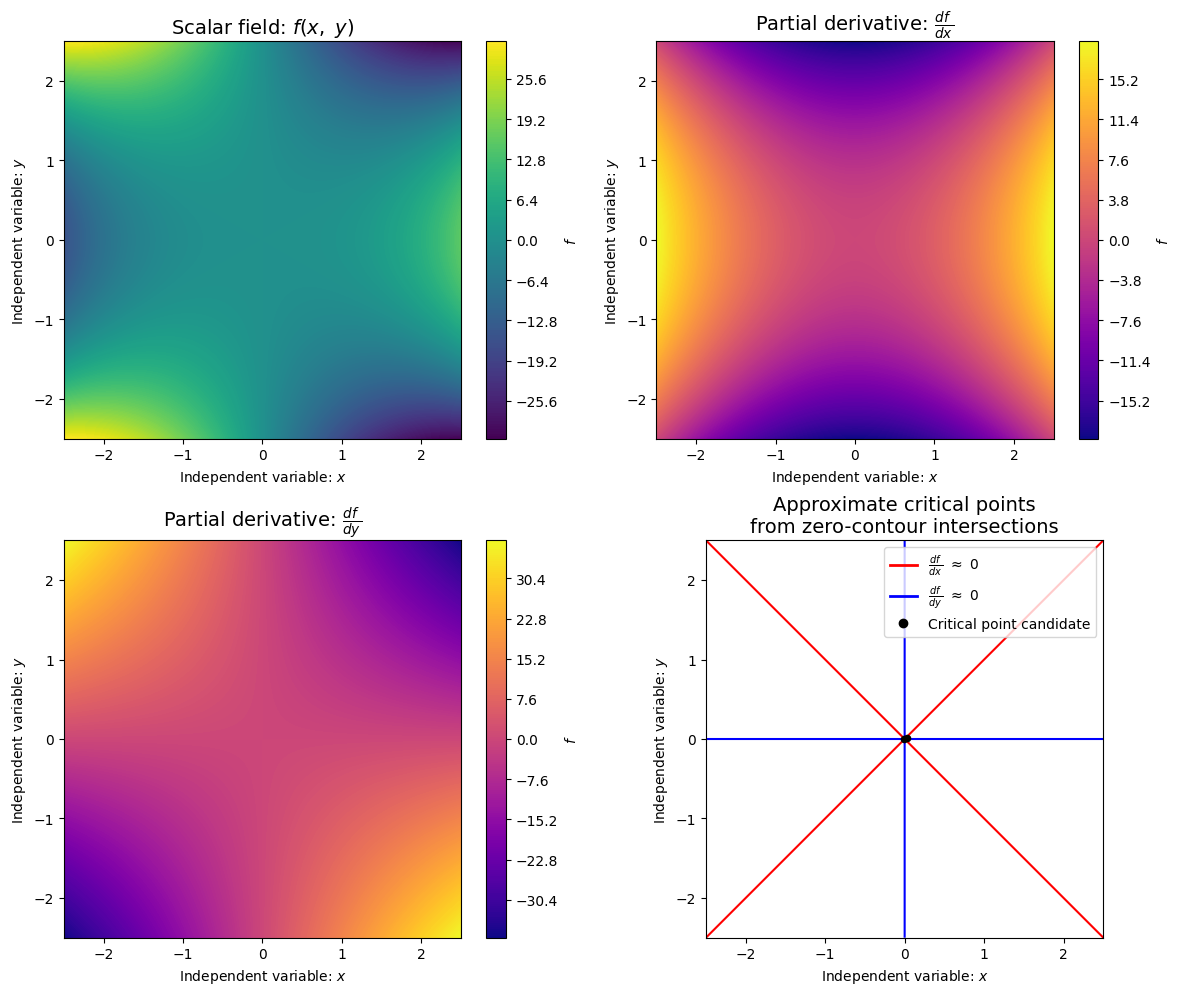

In [12]:
# === 5. Plot a compact summary view ===
fig, axes = plot_analysis_summary(
    result,
    show_filled_field=True,
    show_gradient=False,
)

plt.show()

In [13]:
# === 6. Optional: inspect the Hessian at a candidate point ===
# This is not part of the main numerical pipeline, but it can be useful for
# local interpretation once a candidate has been found.


# === HESSIAN FORMATTING CONFIG ===
# Define column metadata: Name, Width, Justification, Precision, Etc.
COL_EXPR = {"name": "Symbolic Expression", "width": 20, "align": "<"}
COL_LABEL = {"name": "Derivative", "width": 10, "align": "<"}
COL_VALUE = {"name": "Numerical Value", "width": 15, "align": "^"}

COLUMNS = [COL_LABEL, COL_VALUE, COL_EXPR]
MARGIN_CHAR = "="
SEPARATION = "  "  # Spacing char between columns

# Unicode Box Drawing Characters
TOP_LEFT, TOP_RIGHT = "┌", "┐"
MID_LEFT, MID_RIGHT = "│", "│"
BOT_LEFT, BOT_RIGHT = "└", "┘"

MATRIX_VALUE_WIDTH = 8  # Slightly narrower for matrix display
PRECISION = ".2f"
JUSTIFICATION = "^"  # Change to '<', '^', or '>' as needed


# === FORMATTING ENGINE ===
def get_table_assets(columns):
    """Generates a header that accounts for inter-column spacing."""
    header_parts = []
    for c in columns:
        header_parts.append(f"{c['name']:{c['align']}{c['width']}}")

    header = SEPARATION.join(header_parts)
    return header


def format_hessian_rows(entries, subs, columns):
    """Yields rows where every cell is strictly justified and padded."""
    for label, expr in entries:
        val = float(sp.N(expr.subs(subs)))

        # Apply formatting requirements to each specific column
        #   - Label (Col 0),
        #   - Value (Col 1),
        #   - Expression (Col 2)
        c0 = f"{label:{columns[0]['align']}{columns[0]['width']}}"
        c1 = f"{val:{columns[1]['align']}{columns[1]['width']}.4f}"
        c2 = f"{str(expr):{columns[2]['align']}{columns[2]['width']}}"

        yield SEPARATION.join([c0, c1, c2])


def format_matrix_output(matrix, subs, width=MATRIX_VALUE_WIDTH, align=JUSTIFICATION):
    """Formats a SymPy matrix with mathematical brackets and alignment."""
    # 1. Evaluate to float grid
    data = matrix.subs(subs).tolist()

    # 2. Build the rows using dynamic formatting string
    fmt = f"{align}{width}{PRECISION}"
    formatted_rows = [[f"{float(val):{fmt}}" for val in r] for r in data]

    output = ["\nHessian Matrix Form:"]
    n_rows = len(formatted_rows)

    for i, row_data in enumerate(formatted_rows):
        content = " ".join(row_data)

        # 3. Select brackets based on row position
        if n_rows == 1:
            left, right = "[", "]"
        elif i == 0:
            left, right = TOP_LEFT, TOP_RIGHT
        elif i == n_rows - 1:
            left, right = BOT_LEFT, BOT_RIGHT
        else:
            left, right = MID_LEFT, MID_RIGHT

        output.append(f"{left} {content} {right}")

    return "\n".join(output)

# === EXECUTION (Logic Pipeline) ===
if result.critical_points.size != 0:
    for i, point in enumerate(result.critical_points, start=1):
        px, py = point
        substitutions = {x: float(px), y: float(py)}

        # Define the Hessian components
        hessian_data = [
            ("f_xx", sp.diff(result.dfdx, x)),
            ("f_xy", sp.diff(result.dfdx, y)),
            ("f_yx", sp.diff(result.dfdy, x)),
            ("f_yy", sp.diff(result.dfdy, y)),
        ]

        # Generate UI elements
        title = f"=== Hessian Analysis at Point {i}: ({px:.3f}, {py:.3f}) ==="
        header = get_table_assets(COLUMNS)
        margin = MARGIN_CHAR * len(title)

        print(f"\n{title}")
        print(header)
        print(margin)

        for row in format_hessian_rows(hessian_data, substitutions, COLUMNS):
            print(row)

        # Final Matrix Visualization
        H_mat = sp.Matrix(
            [
                [hessian_data[0][1], hessian_data[1][1]],
                [hessian_data[2][1], hessian_data[3][1]],
            ]
        )
        print(format_matrix_output(H_mat, substitutions)+"\n")


=== Hessian Analysis at Point 1: (-0.008, -0.003) ===
Derivative  Numerical Value  Symbolic Expression 
f_xx            -0.0482      6*x                 
f_xy            0.0204       -6*y                
f_yx            0.0204       -6*y                
f_yy            0.0482       -6*x                

Hessian Matrix Form:
┌  -0.05     0.02   ┐
└   0.02     0.05   ┘


=== Hessian Analysis at Point 2: (0.026, 0.011) ===
Derivative  Numerical Value  Symbolic Expression 
f_xx            0.1585       6*x                 
f_xy            -0.0673      -6*y                
f_yx            -0.0673      -6*y                
f_yy            -0.1585      -6*x                

Hessian Matrix Form:
┌   0.16    -0.07   ┐
└  -0.07    -0.16   ┘

